# Imports

In [ ]:
import os
import urllib.request
import base64
import kagglehub
import zipfile

# Check if the dataset already exists locally in the current directory
local_path = "./kth_dataset"

if os.path.exists(local_path) and os.path.isdir(local_path):
    path = local_path
    print(f"Using local dataset found at: {path}")
else:
    print("Local dataset not found. Downloading from Kaggle to safe cache...")

# Define safe download path for the restricted server
safe_cache_dir = "/cephyr/users/domingos/Alvis/data_cache"
os.makedirs(safe_cache_dir, exist_ok=True)
os.environ["KAGGLEHUB_CACHE_DIR"] = safe_cache_dir

# Download the dataset
path = kagglehub.dataset_download("vafaeii/kth-action-recognition-dataset")
print("Path to downloaded dataset files:", path)

100%|██████████████████████████████████████| 1.07G/1.07G [00:26<00:00, 43.1MB/s]

Extracting files...


Path to dataset files: /home/vipactivity/.cache/kagglehub/datasets/vafaeii/kth-action-recognition-dataset/versions/92


In [ ]:
import tensorflow as tf
tf.keras.backend.clear_session()
from tensorflow.keras import layers, models
import cv2
import os
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


# Parameters

In [ ]:
IMG_SIZE = 128
NUM_FRAMES = 16
BATCH_SIZE = 4 # Lowered from 4. 260410

# Dataframe

In [ ]:
data = []

for label in os.listdir(path):

    class_dir = os.path.join(path, label)

    if not os.path.isdir(class_dir):
        continue

    for file in os.listdir(class_dir):

        if file.endswith(".avi"):

            person = file.split("_")[0]

            data.append({
                "filepath": os.path.join(class_dir, file),
                "label": label,
                "person": person
            })

df = pd.DataFrame(data)

print("Total videos:", len(df))
print(df["label"].value_counts())

Total videos: 599
label
running         100
walking         100
jogging         100
boxing          100
handwaving      100
handclapping     99
Name: count, dtype: int64


# Partitioning

In [ ]:
train_people = [f"person{i:02d}" for i in range(1,17)]
test_people  = [f"person{i:02d}" for i in range(17,26)]

train_df = df[df["person"].isin(train_people)].copy()
test_df  = df[df["person"].isin(test_people)].copy()

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 383
Test: 216


# Labeling

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

le.fit(train_df["label"])

train_df["label_id"] = le.transform(train_df["label"])
test_df["label_id"] = le.transform(test_df["label"])

NUM_CLASSES = len(le.classes_)

print("Classes:", le.classes_)

Classes: ['boxing' 'handclapping' 'handwaving' 'jogging' 'running' 'walking']


# Video loader

In [ ]:

video_cache = {}

def load_video(path, num_frames=NUM_FRAMES):

    if path in video_cache:
        return video_cache[path]

    cap = cv2.VideoCapture(path)

    frames = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    step = max(total_frames // num_frames, 1)

    frame_indices = np.arange(0, step * num_frames, step)
    frame_indices = np.clip(frame_indices, 0, total_frames - 1)

    for i in frame_indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()

        if not ret:
            frame = np.zeros((IMG_SIZE, IMG_SIZE, 3))

        else:
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = frame / 255.0

        frames.append(frame)

    if np.random.rand() < 0.5:
        frame = cv2.flip(frame, 1)  # horizontal flip

    # slight brightness change
    frame = frame * (0.8 + 0.4*np.random.rand())
    frame = np.clip(frame, 0, 1)

    cap.release()

    frames = np.array(frames, dtype=np.float32)

    # frame differencing
    motion = np.diff(frames, axis=0)
    motion = motion / (np.std(motion) + 1e-6)
    motion = np.vstack([motion, motion[-1:]])

    frames = motion.reshape((num_frames, IMG_SIZE, IMG_SIZE, 3))

    video_cache[path] = frames

    return frames


# Generator

In [ ]:
def generator(dataframe):

    for _, row in dataframe.iterrows():

        video = load_video(row["filepath"])

        label = row["label_id"]

        yield video, label

# Tensor output signature

In [ ]:
output_signature = (
    tf.TensorSpec(
        shape=(NUM_FRAMES, IMG_SIZE, IMG_SIZE, 3),
        dtype=tf.float32
    ),
    tf.TensorSpec(
        shape=(),
        dtype=tf.int32
    ),
)

# Create Tensor datasets

In [ ]:
train_ds = tf.data.Dataset.from_generator(
    lambda: generator(train_df),
    output_signature=output_signature
)

test_ds = tf.data.Dataset.from_generator(
    lambda: generator(test_df),
    output_signature=output_signature
)

train_ds = (
    train_ds
    .shuffle(100)
    .batch(BATCH_SIZE)
    .repeat()
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Model: CNN + LSTM

In [ ]:
base_cnn = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_cnn.trainable = False

for layer in base_cnn.layers[-10:]: #Test values like -10 before going down to -30 again
    layer.trainable = True


inputs = layers.Input(shape=(NUM_FRAMES, IMG_SIZE, IMG_SIZE, 3))

x = layers.TimeDistributed(base_cnn)(inputs)

x = layers.TimeDistributed(
    layers.GlobalAveragePooling2D()
)(x)

# temporal modeling
x = layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2)(x)

x = layers.Dense(64, activation="relu")(x)

x = layers.Dropout(0.5)(x)


outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

# compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df["label_id"]),
    y=train_df["label_id"]
)

class_weights = dict(enumerate(weights))

# Stopping when model no longer improves
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Enables escape from local minima
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)


callbacks=[early_stop, lr_scheduler]

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 16, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 16, 4, 4, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 16, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,606,854 (9.94 MB)

 Trainable params: 1,081,350 (4.13 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

# Training

In [ ]:
steps_per_epoch = len(train_df) // BATCH_SIZE
validation_steps = len(test_df) // BATCH_SIZE

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weights
)

Epoch 1/30
52/95 ━━━━━━━━━━━━━━━━━━━━ 16s 390ms/step - accuracy: 0.3739 - loss: 1.6061

[mpeg4 @ 0x7acaf400da40] ac-tex damaged at 8 6
[mpeg4 @ 0x7acaf400da40] Error at MB: 74
[mpeg4 @ 0x7acaf402ca80] ac-tex damaged at 8 6
[mpeg4 @ 0x7acaf402ca80] Error at MB: 74
[mpeg4 @ 0x7acaf402ca80] ac-tex damaged at 8 6
[mpeg4 @ 0x7acaf402ca80] Error at MB: 74


95/95 ━━━━━━━━━━━━━━━━━━━━ 133s 724ms/step - accuracy: 0.3430 - loss: 1.6579 - val_accuracy: 0.3009 - val_loss: 1.6775 - learning_rate: 0.0010
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - accuracy: 0.1581 - loss: 1.8673 - val_accuracy: 0.3889 - val_loss: 1.4878 - learning_rate: 0.0010
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 201ms/step - accuracy: 0.2497 - loss: 1.7866 - val_accuracy: 0.5185 - val_loss: 1.3481 - learning_rate: 0.0010
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step - accuracy: 0.2061 - loss: 1.8171 - val_accuracy: 0.5046 - val_loss: 1.2558 - learning_rate: 0.0010
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - accuracy: 0.2339 - loss: 1.6625 - val_accuracy: 0.5463 - val_loss: 1.2726 - learning_rate: 0.0010
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 198ms/step - accuracy: 0.2792 - loss: 1.5824 - val_accuracy: 0.5509 - val_loss: 1.1712 - learning_rate: 0.0010
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 203ms/step - accuracy: 0.2981 - loss: 1.5624 - val

2026-04-17 16:03:48.091625: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


# Model evaluation

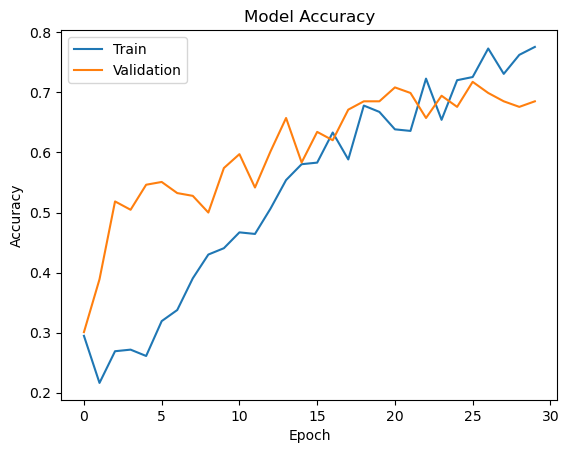

In [ ]:
# print model metrics
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)


plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.savefig("accuracy")
plt.show()

2026-04-17 16:08:55.281757: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Classification report:
              precision    recall  f1-score   support

      boxing       0.97      0.86      0.91        36
handclapping       0.62      0.83      0.71        36
  handwaving       0.70      0.53      0.60        36
     jogging       0.46      0.50      0.48        36
     running       0.68      0.69      0.68        36
     walking       0.70      0.64      0.67        36

    accuracy                           0.68       216
   macro avg       0.69      0.68      0.68       216
weighted avg       0.69      0.68      0.68       216



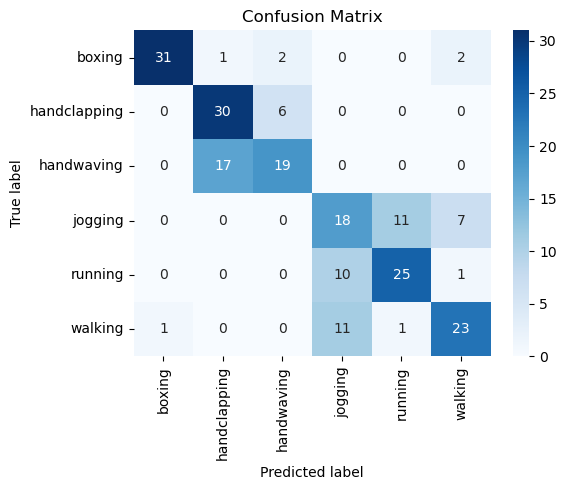

In [ ]:

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for videos, labels in test_ds:

    preds = model.predict(videos, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# -----------------------------
# Compute confusion matrix
# -----------------------------

cm = confusion_matrix(y_true, y_pred)

class_names = le.classes_

print("Classification report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# -----------------------------
# Plot confusion matrix
# -----------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
plt.close()

In [ ]:
model.save("babyjudas_cnn_lstm_v1_170426.keras", include_optimizer=True)
